# CSDA Imagery Download & Site Coverage Optimization: `Planet`
This notebook authenticates with NASA CSDA credentials, loads STAC items alongside search site geometries, filters by cloud cover, optimizes image selection to ensure maximum coverage per search site, downloads imagery assets, and (ToDo) visualizes the results.


| Product Type | Processing Level | Planet API Item Type | Planet API Asset Type Naming | Radiometry & Calibration | Band Configurations |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Basic Scene** | **Level 1B** | `PSScene` | • `basic_analytic_4b`<br>• `basic_analytic_8b` | **Top of Atmosphere (TOA)** radiance. | • 4-band (B, G, R, NIR)<br>• 8-band SuperDove |
| **Ortho Scene (TOA)** | **Level 3B** | `PSScene` | • `ortho_analytic_4b`<br>• `ortho_analytic_8b` | **Top of Atmosphere (TOA)** radiance. | • 4-band (B, G, R, NIR)<br>• 8-band SuperDove |
| **Ortho Scene (SR)** | **Level 3B** | `PSScene` | • `ortho_analytic_4b_sr`<br>• `ortho_analytic_8b_sr` | **Surface Reflectance (SR)** (Atmospherically corrected). | • 4-band (B, G, R, NIR)<br>• 8-band SuperDove |
| **Visual Scene** | **Level 3B** | `PSScene` | • `ortho_visual` | **Color-corrected** and enhanced for human viewing. | • 3-band Visual (RGB) |
| **Ortho Tile** | **Level 3B** | `ortho_tile` | • `ortho_analytic`<br>• `ortho_analytic_sr` | **TOA Radiance** or **Surface Reflectance (SR)**. | • 4-band or 5-band (legacy grid) |


In [19]:
import os
from pathlib import Path

# ==============================================================================
# INPUT CONFIGURATION
# ==============================================================================

# Credential File Path
CREDENTIALS_FILE = Path("/home/pmontesa/code/credentials.ini").expanduser()

YEAR = 'allyears' #2024

# Input STAC Items & GeoPackage File Paths
STAC_ITEMS_JSON = f"/home/pmontesa/code/csda_summaries/notebooks/stac_items_RadCalNet_planet_{YEAR}.json"
STAC_GPKG =       f"/home/pmontesa/code/csda_summaries/notebooks/stac_RadCalNet_planet_{YEAR}.gpkg"
SITES_GPKG =      f"/home/pmontesa/code/csda_summaries/sites/eval_sites_aoi.geojson"  # Path to your search sites shapefile/gpkg

# Output Directory for Downloaded Assets
OUTPUT_DIR = Path("/explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet")

# Filtering & Optimization Settings
MIN_DATE = '2024-01-01'
MAX_CLOUD_COVER = 0.0  # Max cloud cover percentage allowed (0 to 100)
SELECT_TOP_PER_SITE = 1  # Minimum number of best-fitting images to select per site
ASSET_KEY_TO_DOWNLOAD = 'ortho_analytic'  # Asset key in STAC Item (e.g., 'data', 'analytic', 'ortho')
DOWNLOAD_XML_ONLY = False  # Set to True to download XML metadata first before full raster
SITE_ID_COL = 'Site Name' # 'site_id'

# Create output folder if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
STAC_GPKG

'/home/pmontesa/code/csda_summaries/notebooks/stac_RadCalNet_planet_allyears.gpkg'

In [21]:
STAC_ITEMS_JSON

'/home/pmontesa/code/csda_summaries/notebooks/stac_items_RadCalNet_planet_allyears.json'

In [22]:
import configparser
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.plot import show
from matplotlib_scalebar.scalebar import ScaleBar
from pystac import ItemCollection
from httpx import BasicAuth
from csda_client import CsdaClient
import tabulate
import humanize

## 1. NASA CSDA Authentication & Quota Verification

In [23]:
def load_earthdata_creds(path):
    config = configparser.ConfigParser()
    config.read(Path(path).expanduser())
    return config['EarthData']['username'], config['EarthData']['password']

username, password = load_earthdata_creds(CREDENTIALS_FILE)
client = CsdaClient.open(BasicAuth(username=username, password=password))

print(f"Auth Status: {client.verify()}")

# Display user quota profile
profile = client.profile(username)
rows = [[v.vendor, v.quota, v.quota_unit] for v in profile.vendors]
print("\nUser Quotas:")
print(tabulate.tabulate(rows, headers=["Vendor", "Quota", "Quota Unit"], tablefmt="simple"))

Auth Status: Hello montesano, you have a valid token!

User Quotas:
Vendor                                    Quota  Quota Unit
--------------------------------  -------------  ------------------
Airbus U.S.- Optical              1000000000000  QuotaUnit.filesize
Planet                                 10000000  QuotaUnit.area
Satellogic                        1000000000000  QuotaUnit.filesize
Vantor IKONOS (NASA only)                    -1  QuotaUnit.area
Vantor - WorldView 4 (NASA only)             -1  QuotaUnit.filesize
Vantor Legion                     1000000000000  QuotaUnit.filesize
Vantor (NASA only)                           -1  QuotaUnit.area


## 2. Load Data & Optimize Image Selection per Site
We filter by `cloud_cover == MAX_CLOUD_COVER` and calculate spatial intersections with search sites to pick the single best image (maximizing covered site area) for each site.

In [24]:
# 1. Load GeoDataFrames
stac_gdf = gpd.read_file(STAC_GPKG)

# 1. Convert the object column to datetime64
stac_gdf['datetime'] = pd.to_datetime(stac_gdf['datetime'], format='mixed')
# 2. Filter using a UTC-aligned Timestamp (Fixes the TypeError)
stac_gdf = stac_gdf[stac_gdf['datetime'] > pd.Timestamp(MIN_DATE, tz='UTC')]

sites_gdf = gpd.read_file(SITES_GPKG)
sites_gdf = sites_gdf[sites_gdf.Source == 'RadCalNet']

# Ensure CRS match
if stac_gdf.crs != sites_gdf.crs:
    sites_gdf = sites_gdf.to_crs(stac_gdf.crs)

# 2. Filter candidate imagery by Cloud Cover AND STAC Item Type == PSScene
cloud_mask = stac_gdf['pl:cloud_percent'] <= MAX_CLOUD_COVER

# Check ID prefix for 'PSScene-' (excluding PSScene4Band if desired)
is_psscene = stac_gdf['id'].str.startswith('PSScene')

# Combine filters
filtered_stac_gdf = stac_gdf[cloud_mask & is_psscene].copy()

# 3. Calculate Intersection Area with Sites to optimize coverage
equal_area_crs = "EPSG:3338"  # Alaska Albers Equal Area
stac_proj = filtered_stac_gdf.to_crs(equal_area_crs)
sites_proj = sites_gdf.to_crs(equal_area_crs)

#if 'site_id' not in sites_proj.columns:
sites_proj['site_id'] = sites_proj.index

# Spatial overlay intersection
intersection = gpd.overlay(sites_proj, stac_proj[['id', 'geometry']], how='intersection')
intersection['intersect_area_m2'] = intersection.geometry.area

# Rank images for each site by maximum intersecting coverage area
best_matches = (
    intersection.sort_values(by=['Site Name', 'intersect_area_m2'], ascending=[True, False])
    .groupby('Site Name')
    .head(SELECT_TOP_PER_SITE)
)

selected_item_ids = set(best_matches['id'].unique())

# 4. Load STAC ItemCollection and filter with deduplication
ic = ItemCollection.from_file(STAC_ITEMS_JSON)

seen_ids = set()
selected_stac_items = []

for item in ic.items:
    if item.id in selected_item_ids and item.id not in seen_ids:
        selected_stac_items.append(item)
        seen_ids.add(item.id)

print(f"Total Cloud-Free Candidate Images since {MIN_DATE}: {len(filtered_stac_gdf)}")
print(f"Optimized Selected Unique STAC Items for {len(sites_gdf)} Sites: {len(selected_stac_items)}")

Total Cloud-Free Candidate Images since 2024-01-01: 1557
Optimized Selected Unique STAC Items for 6 Sites: 5


### Check the types of data available for download

In [25]:
item = ic[-1]
rows = []
for key, asset in item.assets.items():
    if file_size := asset.ext.file.size:
        humanized_file_size = humanize.naturalsize(file_size)
    else:
        humanized_file_size = None
    if roles := asset.roles:
        humanized_roles = humanize.natural_list(roles)
    else:
        humanized_roles = roles
    rows.append([key, humanized_roles, asset.media_type, humanized_file_size])
tabulate.tabulate(
    rows, headers=["Key", "Roles", "Type", "File size", "Roles"], tablefmt="html"
)

Key,Roles,Type,File size
thumbnail,thumbnail,,
basic_udm2,data,image/tiff,3.1 MB
ortho_udm2,data,image/tiff,5.5 MB
ortho_visual,data,image/tiff,156.2 MB
json_metadata,metadata,application/json,970 Bytes
basic_analytic_8b,data,image/tiff,711.0 MB
ortho_analytic_8b,data,image/tiff,1.2 GB
ortho_analytic_8b_sr,data,image/tiff,1.0 GB
basic_analytic_4b_rpc,data,text/plain,3.3 kB
basic_analytic_8b_xml,metadata,text/xml,12.2 kB


In [26]:
# Standardize both sets to native Python integers
all_site_ids = set(int(x) for x in sites_proj['site_id']) if 'site_id' in sites_proj.columns else set(int(x) for x in sites_proj.index)
covered_site_ids = set(int(x) for x in best_matches['site_id'].unique())

# Calculate missing sites safely
missing_site_ids = sorted(list(all_site_ids - covered_site_ids))
covered_site_ids_sorted = sorted(list(covered_site_ids))

print(f"Covered Sites ({len(covered_site_ids_sorted)}): {covered_site_ids_sorted}")
print(f"Missing Sites ({len(missing_site_ids)}): {missing_site_ids}")

Covered Sites (5): [10, 31, 47, 52, 60]
Missing Sites (1): [63]


In [27]:
# 1. Group the best matches by STAC Image ID
image_coverage = (
    best_matches.groupby('id')
    .agg(
        site_count=('site_id', 'count'),
        covered_sites=('site_id', lambda x: ', '.join(map(str, sorted(x.unique()))))
    )
    .reset_index()
    .rename(columns={'id': 'stac_item_id'})
)

# 2. Display the summary table
print(f"Summary: {len(image_coverage)} images cover {best_matches['site_id'].nunique()} unique sites\n")
display(image_coverage)

Summary: 5 images cover 5 unique sites



,stac_item_id,site_count,covered_sites
0,PSScene-20240920_173243_97_251a,1,60
1,PSScene-20241221_184448_81_250d,1,52
2,PSScene-20241227_104743_05_2515,1,47
3,PSScene-20241228_092356_97_24f4,1,31
4,PSScene-20241231_034629_27_24ae,1,10


## 3. Download Data
Download selected assets or metadata XMLs using the `CsdaClient`.

In [28]:
# Priority order for raster downloads

PREFERRED_RASTER_TYPES = [
    ASSET_KEY_TO_DOWNLOAD,
    # Modern PSScene (8-band & 4-band)
    #"basic_analytic_8b",
    # "ortho_analytic_8b_sr",
    # "ortho_analytic_4b_sr",
     "ortho_analytic_8b",
    # "ortho_analytic_4b",
    # # Legacy PSScene4Band & PSScene3Band
    # "analytic_sr",
    # "analytic",
    # # Visual assets (fallbacks)
    # "ortho_visual",
    # "visual"
]

# Priority order for metadata downloads
PREFERRED_XML_TYPES = [
    #"basic_analytic_8b_xml",
    # "ortho_analytic_8b_sr_xml",
    # "ortho_analytic_4b_sr_xml",
    
    # # Modern PSScene XML types
     "ortho_analytic_8b_xml",
    # "ortho_analytic_4b_xml",

    # "basic_analytic_4b_xml",
    # # Legacy PSScene4Band & PSScene3Band XML types
    # "analytic_xml",
    # "analytic_sr_xml",
    
    # # Generic / Tile XML fallbacks
    # "xml"
]

# List to store information dictionaries for each downloaded image
download_info_list = []
processed_item_ids = set()

for item in selected_stac_items:
    print(f"\nProcessing STAC Item: {item.id}")
    
    # Extract collection name (fallback if collection is not populated)
    collection_name = item.collection_id or item.collection or "csda_data"
    
    # 1. Download XML/Metadata with custom filename
    xml_type = next((k for k in PREFERRED_XML_TYPES if k in item.assets), None)
    if (DOWNLOAD_XML_ONLY or xml_type) and xml_type:
        try:
            ext = ".json" if "json" in xml_type else ".xml"
            xml_filename = f"{collection_name}_{item.id}_{xml_type}{ext}"
            xml_target_path = OUTPUT_DIR / xml_filename
            
            if xml_target_path.exists():
                print(f"  Metadata already downloaded: {xml_target_path}")
            else:
                print(f"  Downloading metadata ({xml_type})...")
                client.download_item(item, xml_type, str(xml_target_path))
                print(f"  Saved metadata to: {xml_target_path}")
        except Exception as e:
            print(f"  Could not download metadata for {item.id}: {e}")

    # 2. Download Primary Raster Asset
    if not DOWNLOAD_XML_ONLY:
        raster_type = next((k for k in PREFERRED_RASTER_TYPES if k in item.assets), None)
        
        if raster_type:
            raster_filename = f"{collection_name}_{item.id}_{raster_type}.tif"
            raster_target_path = OUTPUT_DIR / raster_filename
            
            stac_gdf_sub = stac_gdf[stac_gdf['id'] == item.id].copy()
            
            info_dict = {
                "local_path": str(raster_target_path),
                "stac_gdf": stac_gdf_sub,
                "sites_gdf": sites_gdf,
                "item_id": item.id
            }
            
            if raster_target_path.exists() and raster_target_path.stat().st_size > 0:
                print(f"  File already exists on disk. Skipping download: {raster_target_path}")
                download_info_list.append(info_dict)
                processed_item_ids.add(item.id)
            else:
                print(f"  Downloading raster asset ('{raster_type}')...")
                try:
                    client.download_item(item, raster_type, str(raster_target_path))
                    print(f"  Saved to: {raster_target_path}")
                    download_info_list.append(info_dict)
                    processed_item_ids.add(item.id)
                except Exception as e:
                    print(f"  Download failed for {item.id} ({raster_type}): {e}")


Processing STAC Item: PSScene-20241231_034629_27_24ae
  Saved metadata to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241231_034629_27_24ae_ortho_analytic_8b_xml.xml
  Saved to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241231_034629_27_24ae_ortho_analytic_8b.tif

Processing STAC Item: PSScene-20241228_092356_97_24f4
  Saved metadata to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241228_092356_97_24f4_ortho_analytic_8b_xml.xml
  Saved to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241228_092356_97_24f4_ortho_analytic_8b.tif

Processing STAC Item: PSScene-20241227_104743_05_2515
  Saved metadata to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241227_104743_05_2515_ortho_analytic_8b_xml.xml
  Saved to: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSSc

In [29]:
len(download_info_list)

5

## 4. Visualization & Plotting
Plot one of the downloaded images alongside its corresponding site polygon boundary.

In [51]:
def plot_image(local_path, stac_gdf, sites_gdf, item_id,
               rgb_indices=[0, 1, 2], SITE_NAME_COL='Site Name',  max_dim=1024, ax=None):

    import matplotlib.pyplot as plt
    import rasterio
    from rasterio.plot import show
    from rasterio.warp import transform_bounds, calculate_default_transform, reproject, Resampling
    import contextily as ctx
    import numpy as np
    from matplotlib.ticker import MaxNLocator
    from pyproj import Transformer
    from matplotlib.offsetbox import AnchoredText
    from matplotlib_scalebar.scalebar import ScaleBar
    from shapely.geometry import box
    import os

    print(f'Plotting: {local_path}')
    
    # Filter STAC entry safely without overwriting the parent dataframe variable
    item_gdf = stac_gdf[stac_gdf.id == item_id].iloc[0:1]
    
    if len(item_gdf) == 0:
        print(f"⚠️ Warning: {item_id} not found in stac_gdf")
        return

    collection = item_gdf.collection.iloc[0] if 'collection' in item_gdf.columns else 'Unknown Collection'
    date_str = item_gdf.datetime.iloc[0] if 'datetime' in item_gdf.columns else ''

    try:
        with rasterio.open(local_path) as dataset:
            # 1. Calculate downsampled target dimensions
            h, w = dataset.height, dataset.width
            if max(h, w) > max_dim:
                scale = max_dim / float(max(h, w))
                out_h, out_w = int(h * scale), int(w * scale)
            else:
                out_h, out_w = h, w

            # 2. Read ONLY the downsampled array into memory
            data = dataset.read(
                out_shape=(dataset.count, out_h, out_w),
                resampling=Resampling.bilinear
            )

            # Calculate scaled source transform for the downsampled array
            src_transform = dataset.transform * dataset.transform.scale(
                (w / out_w),
                (h / out_h)
            )

            nodata = dataset.nodata
            dst_crs = 'EPSG:3857'

            # 3. Compute destination transform and dimensions for Web Mercator (EPSG:3857)
            dst_transform, dst_width, dst_height = calculate_default_transform(
                dataset.crs, dst_crs, out_w, out_h, *dataset.bounds
            )

            left, bottom, right, top = transform_bounds(
                dataset.crs, dst_crs, *dataset.bounds
            )

            # 4. Fast Reprojection of downsampled bands
            reprojected = np.zeros((dataset.count, dst_height, dst_width), dtype=data.dtype)
            for i in range(dataset.count):
                reproject(
                    source=data[i],
                    destination=reprojected[i],
                    src_transform=src_transform,
                    src_crs=dataset.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.bilinear,
                )

            # 5. Mask nodata values
            if nodata is not None:
                mask_reproj = np.any(reprojected == nodata, axis=0)
            else:
                mask_reproj = np.all(reprojected == 0, axis=0)

            # Create figure/ax only if ax wasn't passed in
            standalone_plot = False
            if ax is None:
                fig, ax = plt.subplots(figsize=(14, 10))
                standalone_plot = True

            ax.set_xlim(left, right)
            ax.set_ylim(bottom, top)

            # Add Basemap
            ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas,
                            crs=dst_crs, attribution=' ')

            # Safe RGB selection (fallback if requested bands exceed available count)
            valid_rgb = [idx for idx in rgb_indices if idx < dataset.count]
            if len(valid_rgb) < 3:
                valid_rgb = list(range(min(3, dataset.count)))

            img_rgb = np.moveaxis(reprojected[valid_rgb], 0, -1)

            # 6. Contrast Stretch (2nd to 98th percentile)
            img_stretched = np.zeros_like(img_rgb, dtype=np.uint8)
            for i in range(img_rgb.shape[-1]):
                band = img_rgb[..., i].astype(np.float32)
                valid = band[~mask_reproj]
                if len(valid) > 0:
                    p2, p98 = np.percentile(valid, [2, 98])
                else:
                    p2, p98 = band.min(), band.max()
                stretched = np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1) * 255
                img_stretched[..., i] = stretched.astype(np.uint8)

            alpha = (~mask_reproj * 255).astype(np.uint8)
            
            # Tile RGBA channels
            if img_stretched.shape[-1] == 3:
                rgba = np.dstack([img_stretched, alpha])
            else:
                rgba = img_stretched

            ax.imshow(rgba, extent=(left, right, bottom, top), zorder=2)

            # 7. Plot STAC Footprint
            item_gdf.to_crs(3857).plot(
                ax=ax,
                facecolor='none',
                edgecolor='black',
                linestyle='--',
                linewidth=2.5,
                zorder=3,
            )

            # 8. Plot Intersecting Sites
            raster_footprint_3857 = box(left, bottom, right, top)
            sites_3857 = sites_gdf.to_crs('EPSG:3857')
            intersecting_sites = sites_3857[sites_3857.intersects(raster_footprint_3857)]

            if len(intersecting_sites) > 0:
                intersecting_sites.plot(
                    ax=ax,
                    facecolor='none',
                    edgecolor='red',
                    linestyle='--',
                    linewidth=1.5,
                    zorder=3,
                )

                for _, s in intersecting_sites.iterrows():
                    SITE_NAME = str(s.get(SITE_NAME_COL, s.get('name', 'Site')))
                    c = s.geometry.centroid
                    ax.annotate(
                        SITE_NAME,
                        xy=(c.x, c.y),
                        fontsize=9, color='red', weight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  alpha=0.7, edgecolor='none'),
                        zorder=4,
                    )

            # 9. Axis ticks -> Lat/Lon
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

            transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

            x_ticks = ax.get_xticks()
            mid_y = (bottom + top) / 2
            lons, _ = transformer.transform(x_ticks, [mid_y] * len(x_ticks))
            ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])

            y_ticks = ax.get_yticks()
            mid_x = (left + right) / 2
            _, lats = transformer.transform([mid_x] * len(y_ticks), y_ticks)
            ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],
                                rotation=90, 
                                va="center",         # Centers the rotated label vertically on the tick
                                rotation_mode="anchor"
                                )

            ax.set_xlabel('Longitude', fontsize=9, labelpad=4)
            ax.set_ylabel('Latitude', fontsize=9, labelpad=4)
            ax.tick_params(axis='both', which='major', labelsize=8)

            scalebar = ScaleBar(dx=1, units='m', location='lower right', length_fraction=0.2, box_alpha=0.7)
            ax.add_artist(scalebar)

            ax.set_title(f'{collection} | {date_str} | {SITE_NAME}',
                         fontsize=14, color='#333', loc='left', pad=6)

            ax.annotate(os.path.basename(local_path),
                        xy=(0.02, 0.02), xycoords='axes fraction',
                        fontsize=8, color='#555',
                        verticalalignment='bottom',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    except Exception as e:
        print(f"⚠️ Error rendering {local_path}: {e}")
        if ax is not None:
            ax.text(0.5, 0.5, f"Render Error\n{item_id}", ha='center', va='center', color='red', transform=ax.transAxes)

    if standalone_plot:
        plt.show()

In [52]:
import pickle
from pathlib import Path

# Path to output directory
save_path = OUTPUT_DIR / f"download_info_list_{YEAR}.pkl"

with open(save_path, "wb") as f:
    pickle.dump(download_info_list, f)

print(f"Successfully saved download_info_list ({len(download_info_list)} items) to:")
print(save_path)

Successfully saved download_info_list (5 items) to:
/explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/download_info_list_allyears.pkl


Loaded 5 items from download_info_list_allyears.pkl
Total rasters to plot across both years: 5

Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241231_034629_27_24ae_ortho_analytic_8b.tif


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],


Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241228_092356_97_24f4_ortho_analytic_8b.tif


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],


Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241227_104743_05_2515_ortho_analytic_8b.tif


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],


Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20241221_184448_81_250d_ortho_analytic_8b.tif


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],


Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/planet_PSScene-20240920_173243_97_251a_ortho_analytic_8b.tif


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2937359/2670284105.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lats],


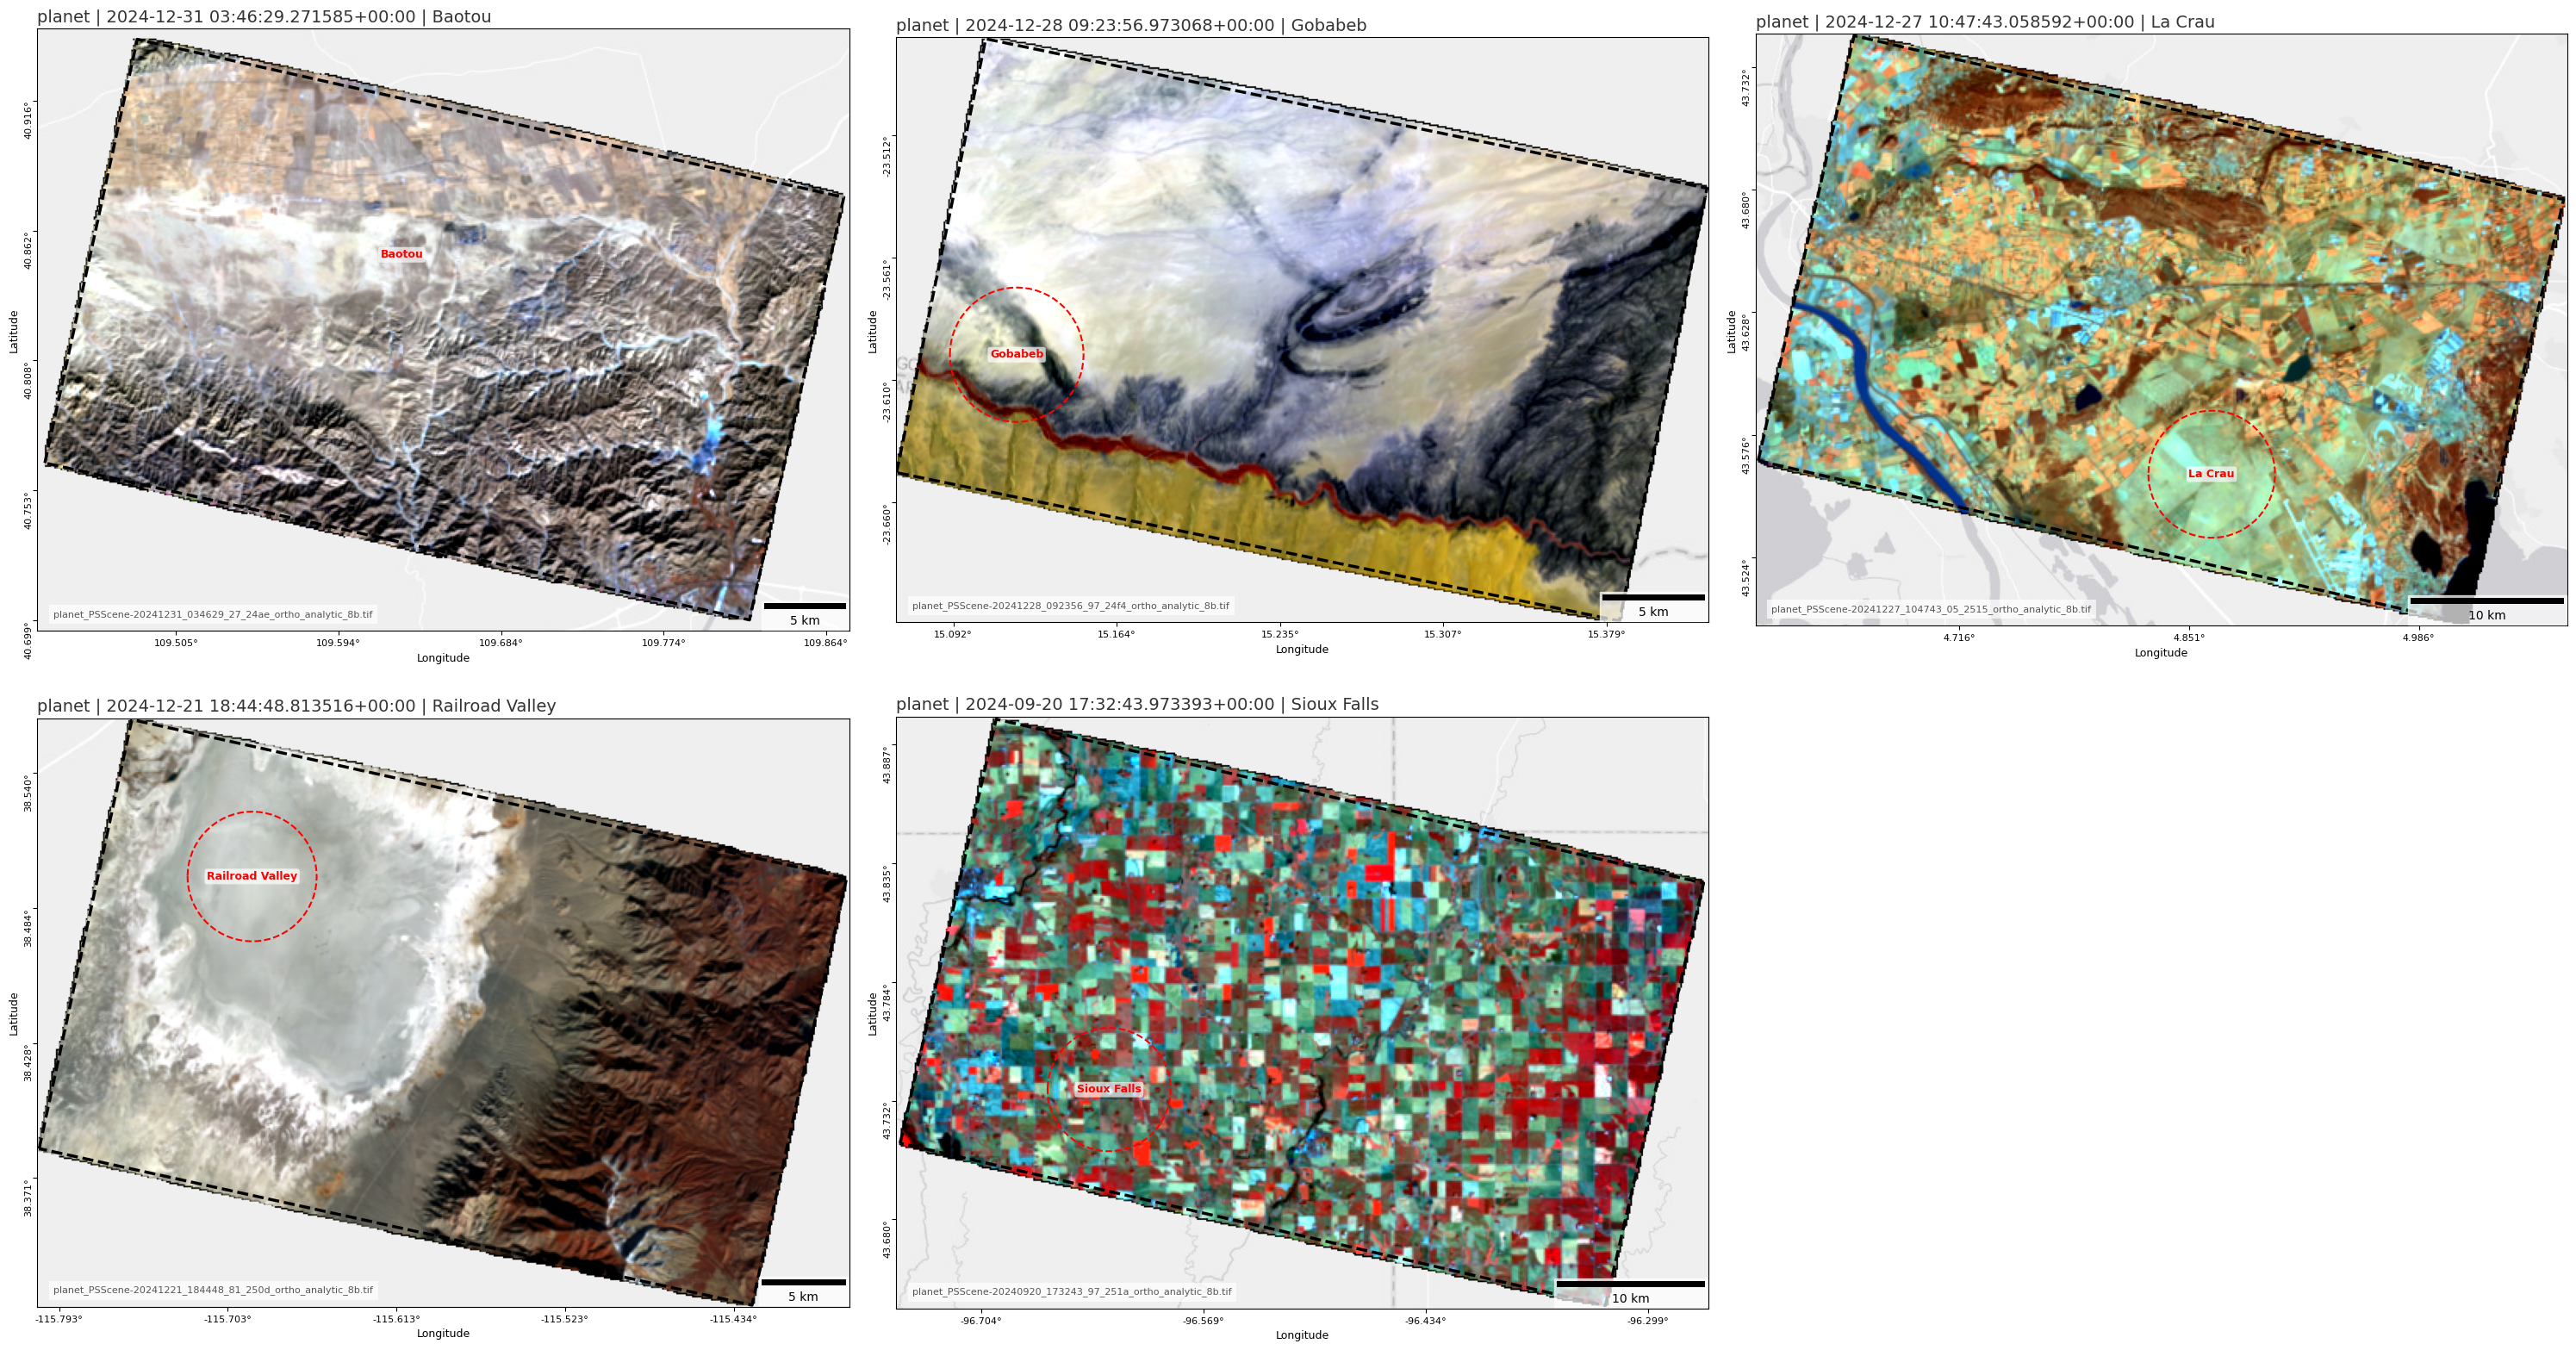

In [56]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

# 1. Define file paths for both years
pkl_2024 = Path("/explore/nobackup/projects/CSDA_eval/csda_download/radcalnet_planet/download_info_list_allyears.pkl")

# 2. Read both pickle files
download_info_list_all = []

for pkl_path in [pkl_2024]:
    if pkl_path.exists():
        with open(pkl_path, "rb") as f:
            year_data = pickle.load(f)
            download_info_list_all.extend(year_data)
            print(f"Loaded {len(year_data)} items from {pkl_path.name}")
    else:
        print(f"⚠️ Warning: File not found - {pkl_path}")

total_items = len(download_info_list_all)
print(f"Total rasters to plot across both years: {total_items}\n")

# 3. Setup grid layout if items exist
if total_items > 0:
    ncols = 3
    nrows = (total_items + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 8 * nrows))

    # Safely flatten axes array regardless of dimensions
    if total_items == 1:
        axes_flat = [axes]
    elif hasattr(axes, 'flatten'):
        axes_flat = axes.flatten()
    else:
        axes_flat = axes

    # 4. Loop through combined list and plot
    if '_8b' in download_info_list_all[0]["local_path"]: 
        RGB = [7,6,3]
    else: 
        RGB = [3,2,1]
    for i, info in enumerate(download_info_list_all):
        plot_image(
            local_path=info["local_path"],
            stac_gdf=info["stac_gdf"],
            sites_gdf=info["sites_gdf"],
            item_id=info["item_id"],
            rgb_indices=RGB,
            max_dim=512,
            ax=axes_flat[i]
        )

    # 5. Hide empty unused subplots in the grid
    for j in range(total_items, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No items were loaded to plot.")